In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS AND GLOBAL CONFIG
# ══════════════════════════════════════════════════════════════════
# Purpose: Import all libraries needed for plotting, set up shared
# constants (model names, colors, paths) used across every figure
# in this notebook, and load all 6 combinations of both the global
# and emotion-conditioned λ probing results from the 4k results
# folder into memory.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

BASE_PATH = "/Users/harshaggarwal/Projects_4/hinemo_project/models"
RESULTS_DIR = f"{BASE_PATH}/phase7a_probing_results_4k_lambda"
SAVE_DIR = f"{BASE_PATH}/figures/phase7a_4k_lambda_probing_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

models = [
    "bert-base-multilingual-cased",
    "muril-base-cased",
    "xlm-roberta-base"
]
states   = ["pretrained", "finetuned"]
EMOTIONS = ["anger", "disgust", "joy", "sadness"]
layers   = list(range(1, 13))

model_short = {
    "bert-base-multilingual-cased": "mBERT",
    "muril-base-cased"            : "MuRIL",
    "xlm-roberta-base"            : "XLM-R"
}

model_colors = {
    "bert-base-multilingual-cased": "blue",
    "muril-base-cased"            : "green",
    "xlm-roberta-base"            : "red"
}

emotion_colors = {
    "anger"  : "#e74c3c",
    "disgust": "#9b59b6",
    "joy"    : "#f39c12",
    "sadness": "#3498db"
}

# Load global probing results (Phase 7a global)
global_results = {}
for model in models:
    for state in states:
        path = f"{RESULTS_DIR}/{model}/probing_{state}.json"
        with open(path) as f:
            global_results[(model, state)] = json.load(f)

# Load emotion-conditioned probing results (Phase 7a emotion-conditioned)
emotion_results = {}
for model in models:
    for state in states:
        path = f"{RESULTS_DIR}/{model}/emotion_probing_{state}.json"
        with open(path) as f:
            emotion_results[(model, state)] = json.load(f)

print("Loaded all 4k results.")
print(f"Global combinations:  {len(global_results)}")
print(f"Emotion combinations: {len(emotion_results)}")

Loaded all 4k results.
Global combinations:  6
Emotion combinations: 6


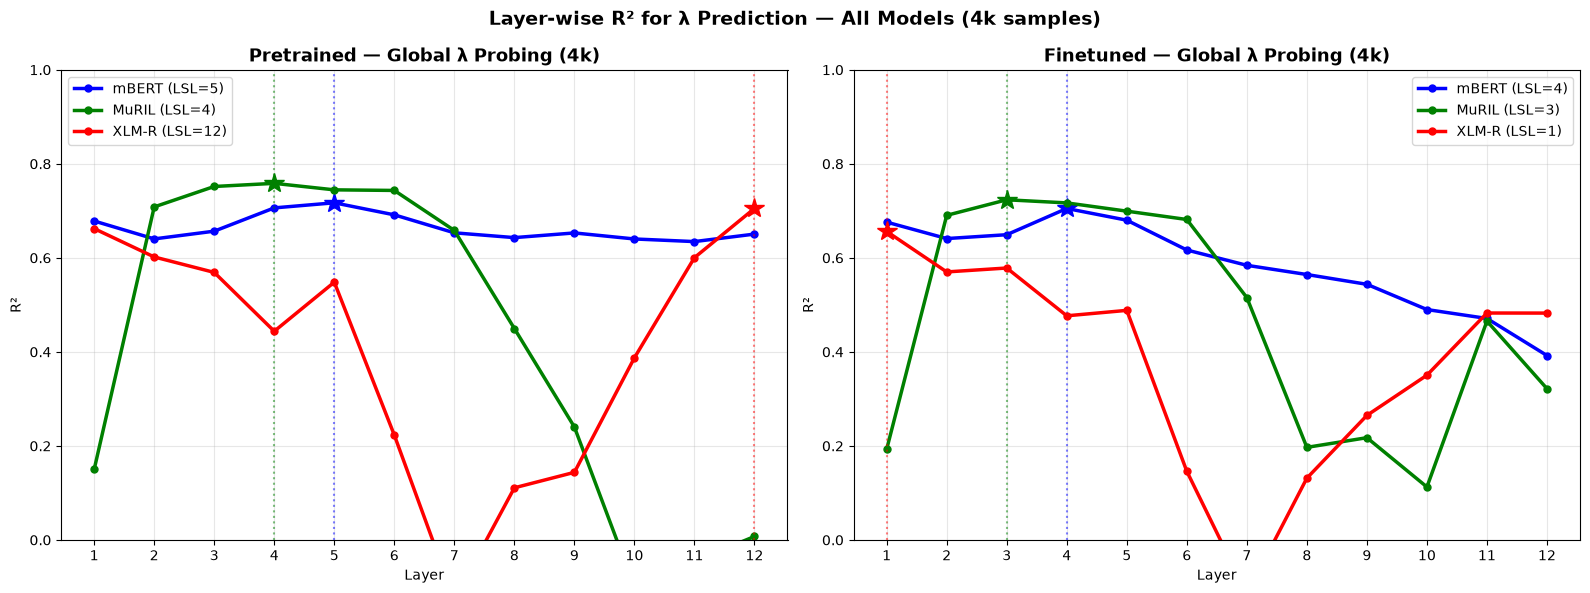

Saved.


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — FIGURE 1: GLOBAL R² CURVES (PRETRAINED VS FINETUNED)
# ══════════════════════════════════════════════════════════════════
# Purpose: Plot the global λ probing R² across all 12 layers, one
# line per model, split into two panels (pretrained / finetuned).
# Stars mark each model's LSL (peak layer). This is the primary
# RQ1 figure — shows at which layer each model best encodes Hindi
# vs English dominance, and how fine-tuning shifts that layer.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col, state in enumerate(states):
    ax = axes[col]

    for model in models:
        r        = global_results[(model, state)]
        r2_curve = r["r2_per_layer"]
        lsl      = r["LSL"]

        ax.plot(layers, r2_curve,
                label=f"{model_short[model]} (LSL={lsl})",
                color=model_colors[model],
                linewidth=2.5,
                marker="o",
                markersize=5)

        ax.axvline(x=lsl, color=model_colors[model], linestyle=":", alpha=0.5)
        ax.plot(lsl, r2_curve[lsl-1], marker="*",
                color=model_colors[model], markersize=15)

    ax.set_title(f"{state.capitalize()} — Global λ Probing (4k)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("R²")
    ax.set_xticks(layers)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise R² for λ Prediction — All Models (4k samples)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/global_r2_curves_4k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

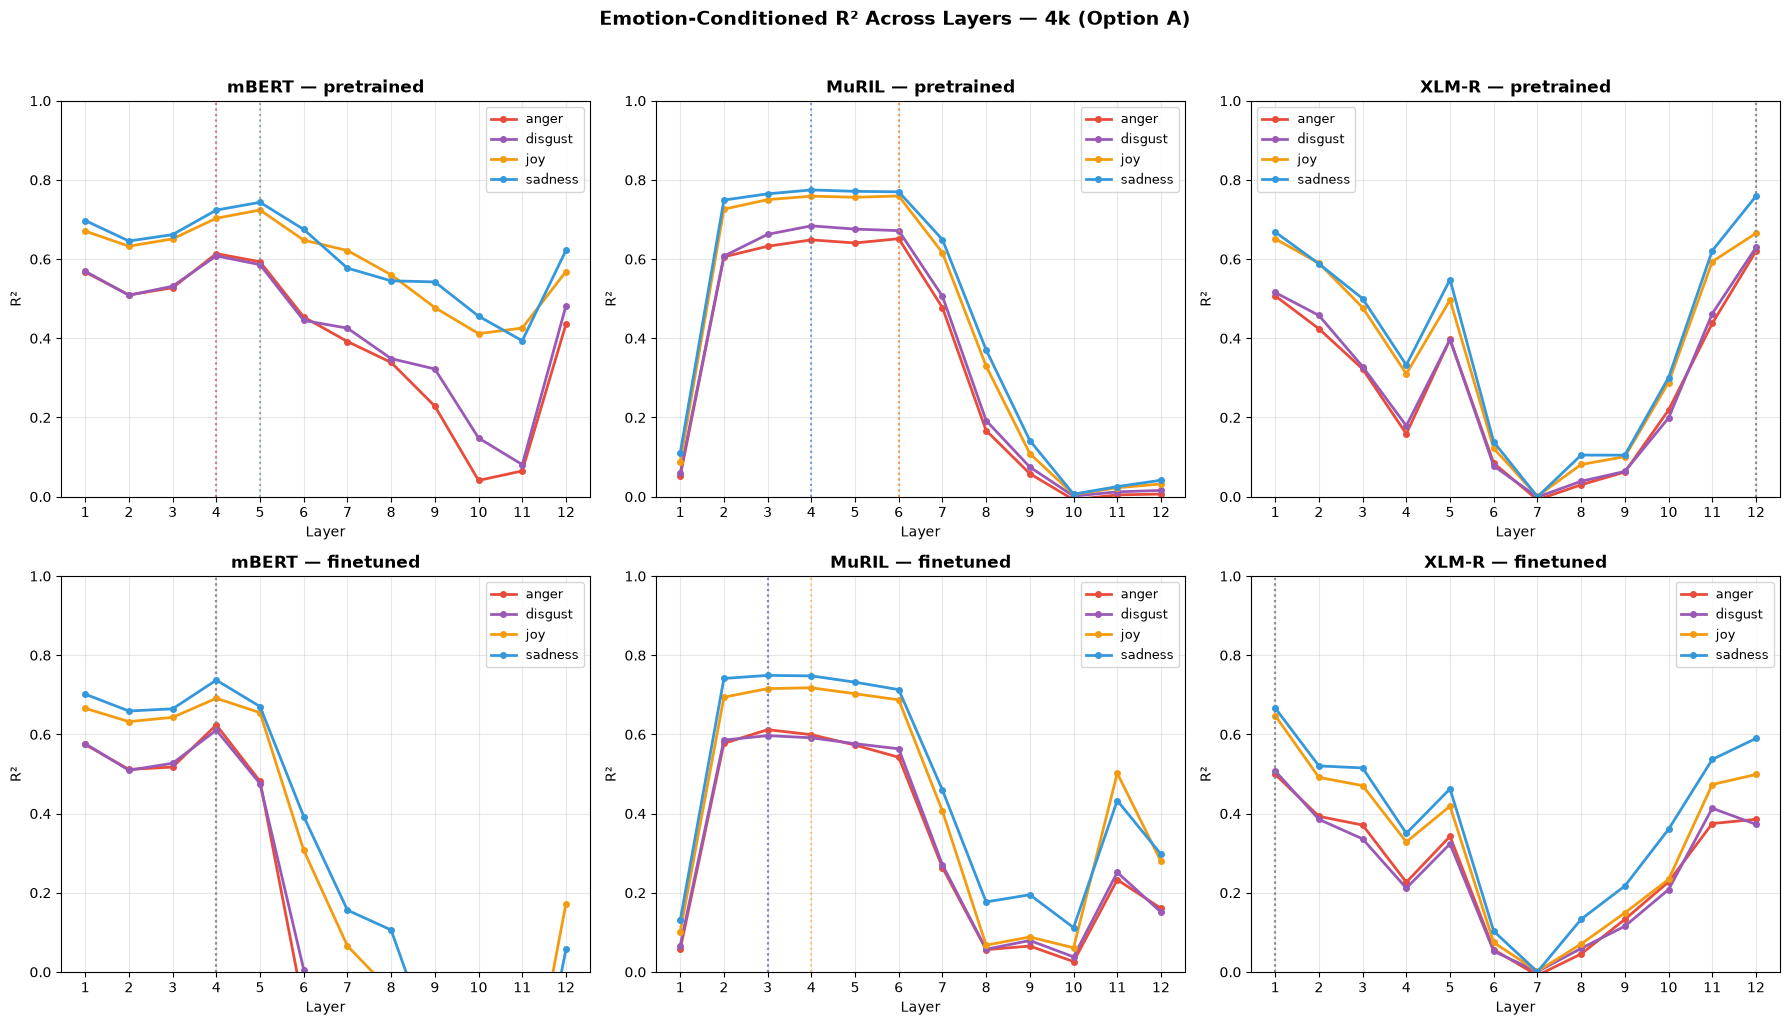

Saved.


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — FIGURE 2 (OPTION A): PER MODEL PER STATE, ONE LINE PER
# EMOTION
# ══════════════════════════════════════════════════════════════════
# Purpose: 6 subplots (3 models × 2 states). Each subplot shows the
# R² curve for all 4 emotions separately, with a dotted vertical
# line marking each emotion's individual LSL. This is where you
# can see whether emotions diverge from each other in language
# encoding depth within a single model/state combination.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, model in enumerate(models):
    for row, state in enumerate(states):
        ax = axes[row, col]
        r  = emotion_results[(model, state)]

        for emotion in EMOTIONS:
            r2_curve = r["r2_per_emotion"][emotion]
            lsl      = r["lsl_per_emotion"][emotion]
            ax.plot(layers, r2_curve,
                    label=emotion,
                    color=emotion_colors[emotion],
                    linewidth=2,
                    marker="o",
                    markersize=4)
            ax.axvline(x=lsl, color=emotion_colors[emotion],
                       linestyle=":", alpha=0.5)

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("R²")
        ax.set_xticks(layers)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Emotion-Conditioned R² Across Layers — 4k (Option A)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/optionA_per_model_per_state_4k.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

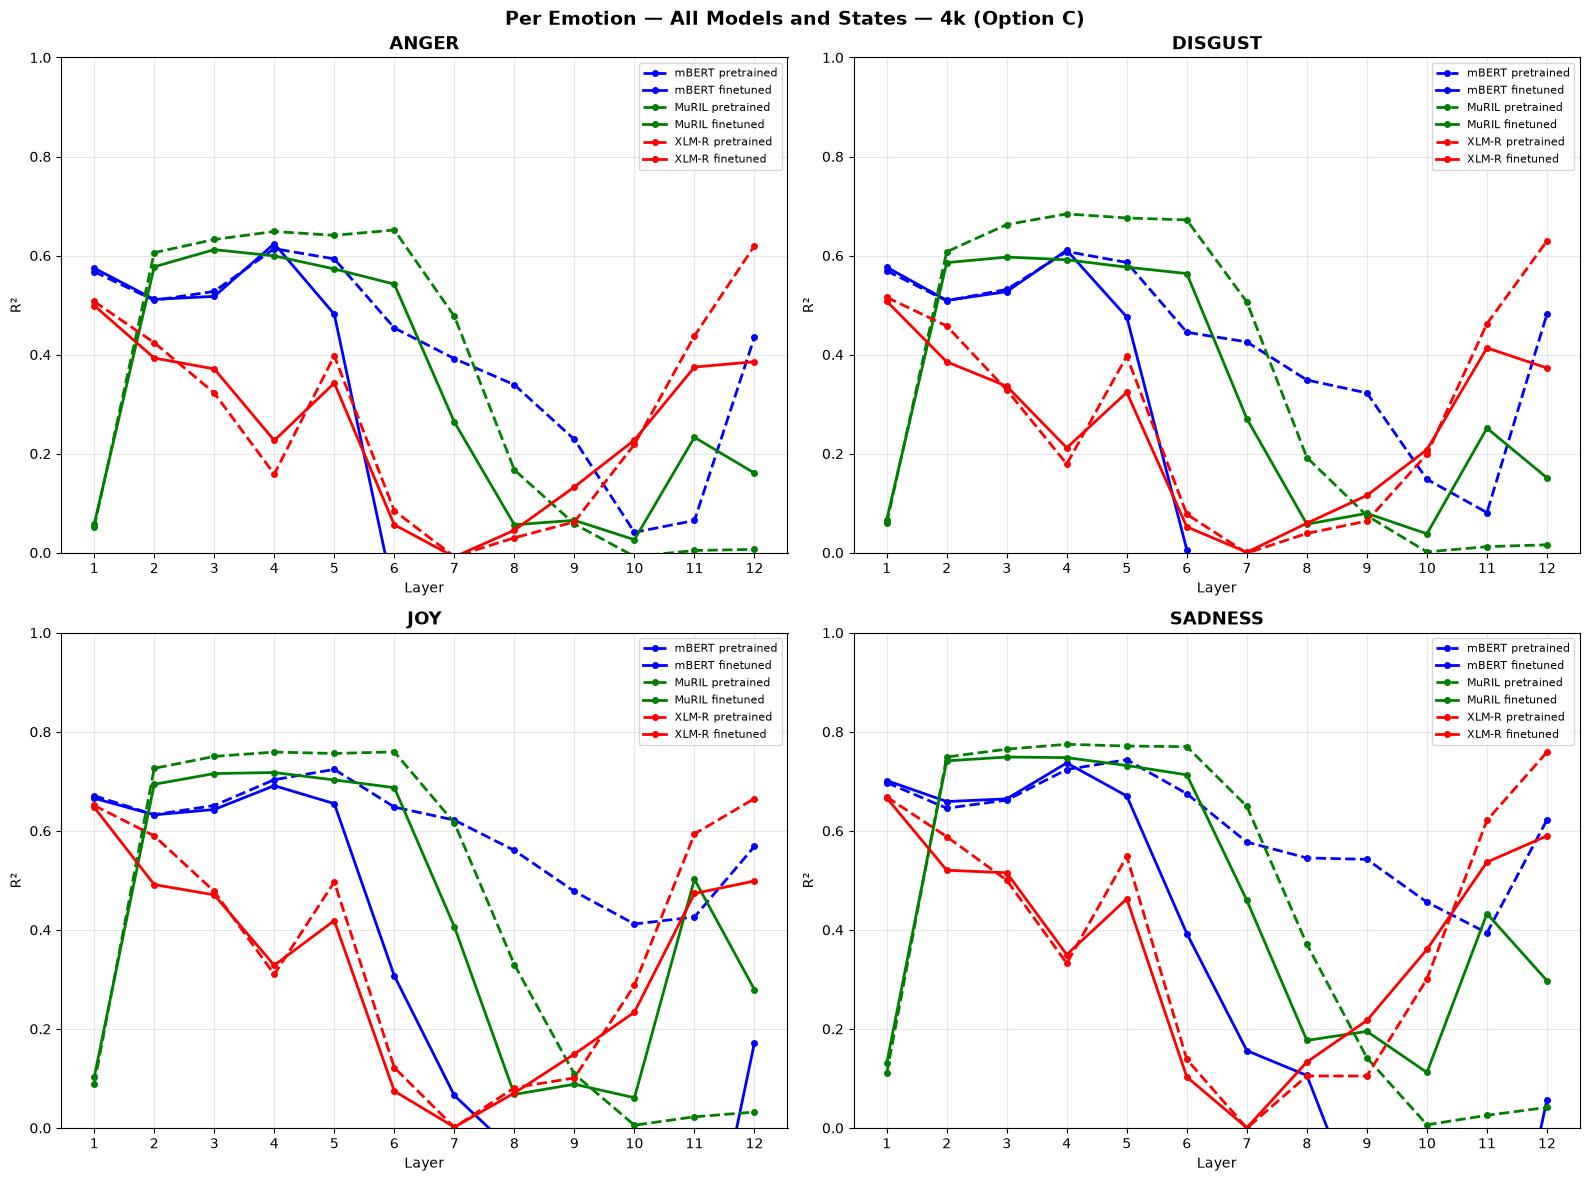

Saved.


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — FIGURE 3 (OPTION C): PER EMOTION ACROSS ALL MODELS
# ══════════════════════════════════════════════════════════════════
# Purpose: 4 subplots, one per emotion. Each subplot shows 6 lines
# (3 models × 2 states) so you can see whether a given emotion
# (e.g. anger) behaves consistently across architectures, or
# whether each model encodes that emotion's language dominance
# differently. Dashed = pretrained, solid = finetuned.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_state_styles = {
    ("bert-base-multilingual-cased", "pretrained"): ("blue",  "--", "mBERT pretrained"),
    ("bert-base-multilingual-cased", "finetuned"):  ("blue",  "-",  "mBERT finetuned"),
    ("muril-base-cased",             "pretrained"): ("green", "--", "MuRIL pretrained"),
    ("muril-base-cased",             "finetuned"):  ("green", "-",  "MuRIL finetuned"),
    ("xlm-roberta-base",             "pretrained"): ("red",   "--", "XLM-R pretrained"),
    ("xlm-roberta-base",             "finetuned"):  ("red",   "-",  "XLM-R finetuned"),
}

for idx, emotion in enumerate(EMOTIONS):
    ax = axes[idx]

    for (model, state), (color, linestyle, label) in model_state_styles.items():
        r2_curve = emotion_results[(model, state)]["r2_per_emotion"][emotion]
        ax.plot(layers, r2_curve, label=label, color=color,
                linestyle=linestyle, linewidth=2, marker="o", markersize=4)

    ax.set_title(f"{emotion.upper()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("R²")
    ax.set_xticks(layers)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Per Emotion — All Models and States — 4k (Option C)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/optionC_per_emotion_4k.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

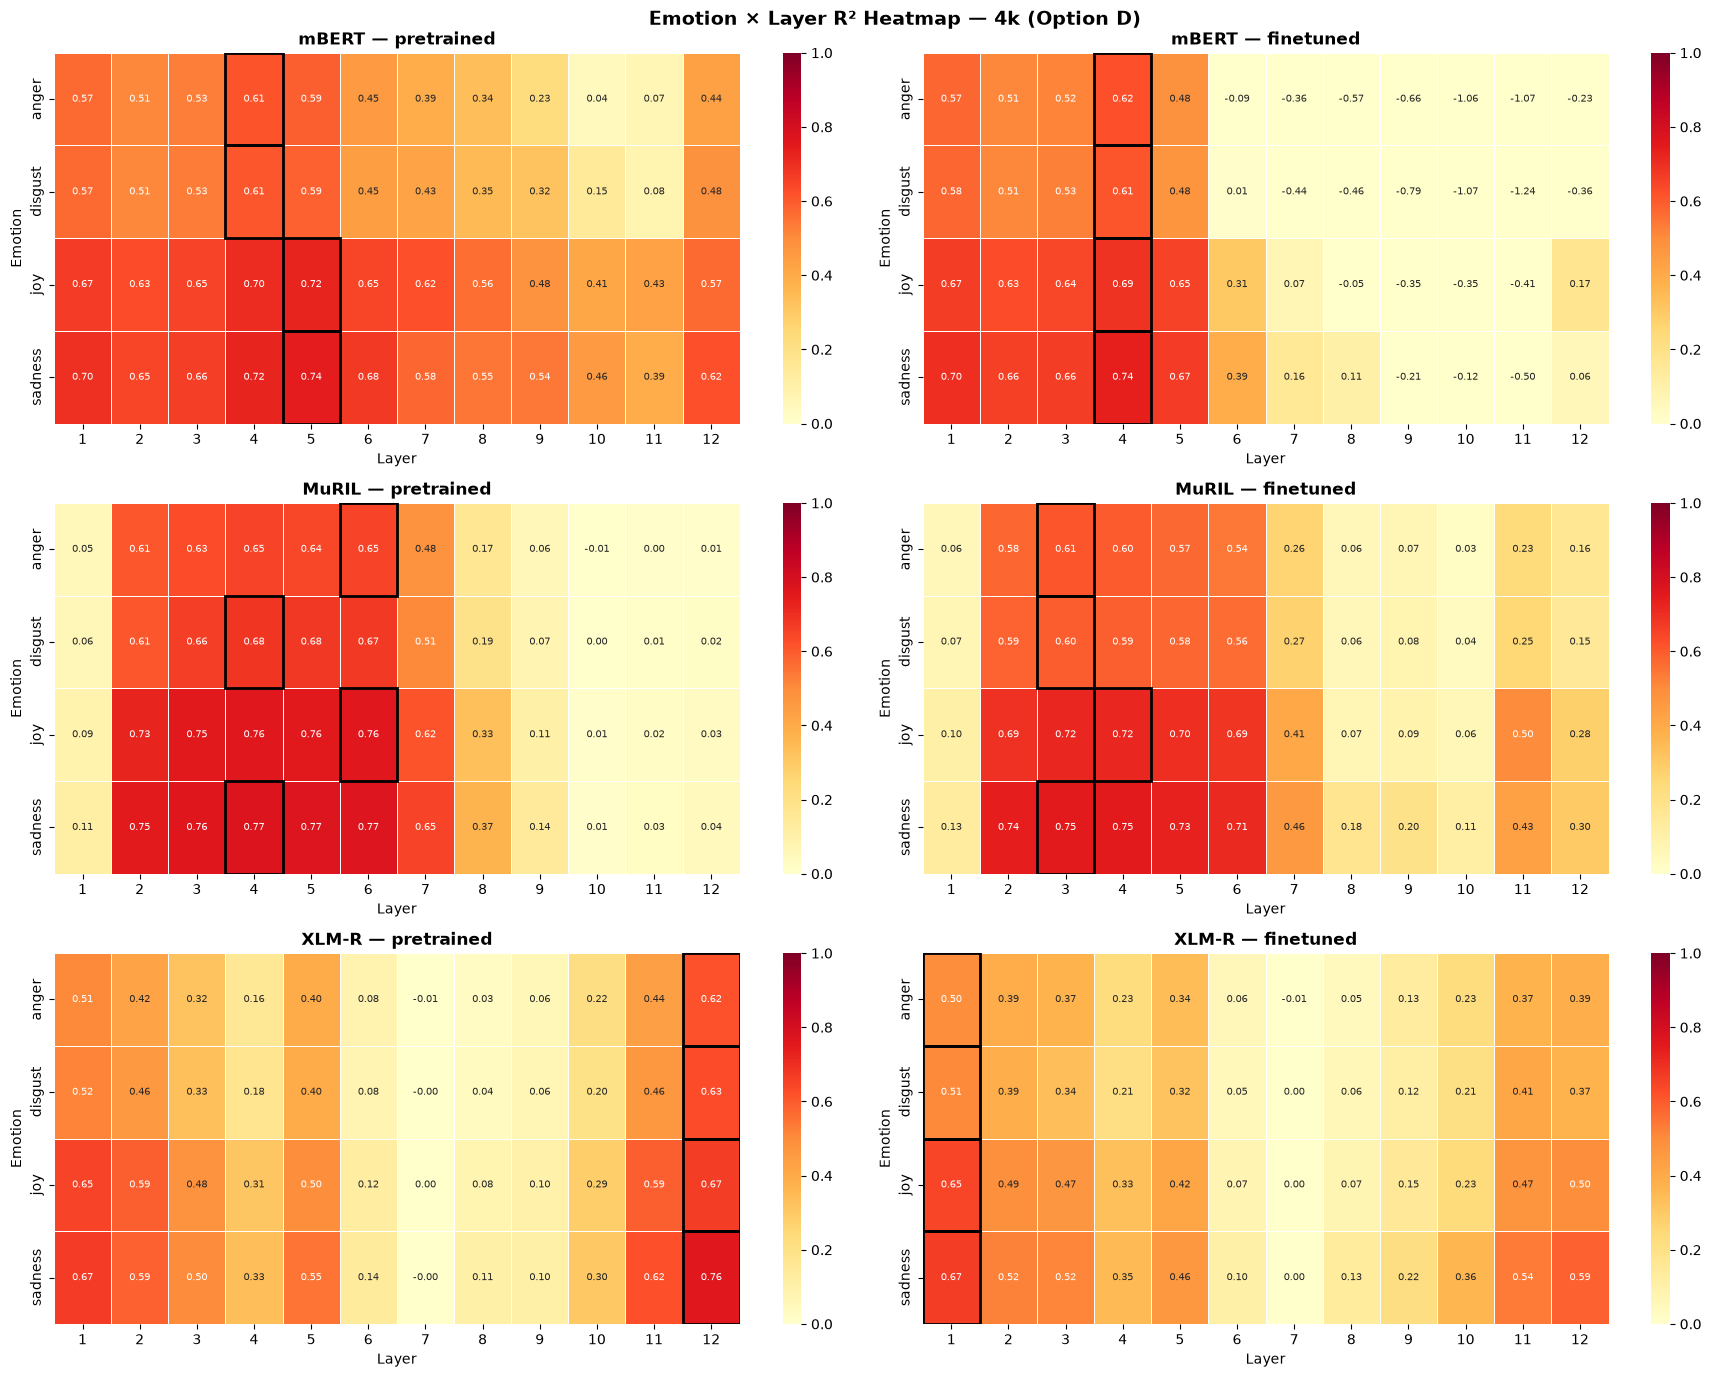

Saved.


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 — FIGURE 4 (OPTION D): HEATMAP OF EMOTION × LAYER R²
# ══════════════════════════════════════════════════════════════════
# Purpose: 6 heatmaps (3 models × 2 states). Rows = emotions,
# columns = layers 1-12, color = R². A black box marks each
# emotion's LSL. This is the figure specified in your progress doc
# as the paper figure for RQ2 — visually shows whether all 4
# emotions peak in the same column (no differentiation) or spread
# across different columns (differentiation, i.e. high ELDS).
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

for row, model in enumerate(models):
    for col, state in enumerate(states):
        ax = axes[row, col]
        r  = emotion_results[(model, state)]

        matrix = np.array([
            r["r2_per_emotion"][emotion] for emotion in EMOTIONS
        ])

        sns.heatmap(
            matrix, ax=ax, vmin=0, vmax=1, cmap="YlOrRd",
            xticklabels=[str(l) for l in layers],
            yticklabels=EMOTIONS,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.5, linecolor="white", cbar=True
        )

        for e_idx, emotion in enumerate(EMOTIONS):
            lsl = r["lsl_per_emotion"][emotion]
            ax.add_patch(plt.Rectangle(
                (lsl-1, e_idx), 1, 1, fill=False,
                edgecolor="black", lw=2
            ))

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Emotion")

plt.suptitle("Emotion × Layer R² Heatmap — 4k (Option D)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/optionD_heatmap_4k.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 — SIDE-BY-SIDE COMPARISON: 3k vs 4k ELDS
# ══════════════════════════════════════════════════════════════════
# Purpose: Load the 3k emotion-conditioned results alongside the 4k
# ones and print a comparison table. This documents, in the same
# notebook as the 4k figures, exactly which ELDS values were
# stable across sample sizes and which changed — directly
# supporting the "sample size sensitivity" limitation noted for
# MuRIL.
# ══════════════════════════════════════════════════════════════════

RESULTS_DIR_3K = f"{BASE_PATH}/phase7a_probing_results_3k_lambda"

print(f"{'Model':<35} {'State':<12} {'ELDS (3k)':<12} {'ELDS (4k)':<12} {'Stable?'}")
print("-" * 85)

for model in models:
    for state in states:
        path_3k = f"{RESULTS_DIR_3K}/{model}/emotion_probing_{state}.json"
        path_4k = f"{RESULTS_DIR}/{model}/emotion_probing_{state}.json"

        with open(path_3k) as f:
            r3 = json.load(f)
        with open(path_4k) as f:
            r4 = json.load(f)

        stable = "Yes" if abs(r3["ELDS"] - r4["ELDS"]) < 0.3 else "NO — unstable"

        print(f"{model:<35} {state:<12} {r3['ELDS']:<12.4f} {r4['ELDS']:<12.4f} {stable}")

Model                               State        ELDS (3k)    ELDS (4k)    Stable?
-------------------------------------------------------------------------------------
bert-base-multilingual-cased        pretrained   0.6667       0.6667       Yes
bert-base-multilingual-cased        finetuned    0.0000       0.0000       Yes
muril-base-cased                    pretrained   0.0000       1.3333       NO — unstable
muril-base-cased                    finetuned    1.1667       0.5000       NO — unstable
xlm-roberta-base                    pretrained   0.0000       0.0000       Yes
xlm-roberta-base                    finetuned    0.0000       0.0000       Yes
